# Yaw Perturbation $\Delta\psi$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy
from sympy import Derivative, Matrix, Symbol, cos, sin

f = Symbol("f")
xc = Symbol("x_c")
yc = Symbol("y_c")

# Original camera pose
phi = Symbol("phi")  # Roll
theta = Symbol("theta")  # Pitch
psi = Symbol("psi")  # Yaw
x = Symbol("x")
y = Symbol("y")
# Non-zero otherwise degenerate homography since camera center aligned with plane
z = Symbol("z", nonzero=True)

# Viewpoint delta
dphi = Symbol("\Delta\phi")  # Roll
dtheta = Symbol("\Delta\\theta")  # Pitch
dpsi = Symbol("\Delta\psi")  # Yaw
dx = Symbol("\Delta x")
dy = Symbol("\Delta y")
dz = Symbol("\Delta z")

## Define homography matrix

In [2]:
H_inv = Matrix(
    [
        [cos(dpsi) - xc * sin(dpsi) / f, 0, (f**2 + xc**2) * sin(dpsi) / f],
        [-yc * sin(dpsi) / f, 1, (yc * (f * cos(dpsi) - f) + xc * sin(dpsi)) / f],
        [-sin(dpsi) / f, 0, cos(dpsi) + xc * sin(dpsi) / f],
    ]
)
H_inv

Matrix([
[cos(\Delta\psi) - x_c*sin(\Delta\psi)/f, 0,                     (f**2 + x_c**2)*sin(\Delta\psi)/f],
[                 -y_c*sin(\Delta\psi)/f, 1, (x_c*sin(\Delta\psi) + y_c*(f*cos(\Delta\psi) - f))/f],
[                     -sin(\Delta\psi)/f, 0,               cos(\Delta\psi) + x_c*sin(\Delta\psi)/f]])

## Apply projective transform

In [3]:
u = Symbol("u")
v = Symbol("v")

p0 = H_inv @ Matrix([u, v, 1])
p0 = p0 / p0[2]  # Normalize for non-homogeneous coordinates
p0 = sympy.simplify(p0)

u0 = p0[0]
v0 = p0[1]

In [4]:
u0

(u*(f*cos(\Delta\psi) - x_c*sin(\Delta\psi)) + (f**2 + x_c**2)*sin(\Delta\psi))/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))

In [5]:
u0.expand()

f**2*sin(\Delta\psi)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi)) + f*u*cos(\Delta\psi)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi)) - u*x_c*sin(\Delta\psi)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi)) + x_c**2*sin(\Delta\psi)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))

In [6]:
v0

(f*v + f*y_c*(cos(\Delta\psi) - 1) - u*y_c*sin(\Delta\psi) + x_c*sin(\Delta\psi))/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))

In [7]:
u0_bis = xc + f * (f * sin(dpsi) + (u - xc) * cos(dpsi)) / (
    f * cos(dpsi) - (u - xc) * sin(dpsi)
)
u0_bis

f*(f*sin(\Delta\psi) + (u - x_c)*cos(\Delta\psi))/(f*cos(\Delta\psi) - (u - x_c)*sin(\Delta\psi)) + x_c

In [14]:
(u0 - u0_bis).expand().simplify()

0

In [16]:
v0_bis = yc + f * (v - yc) / (f * cos(dpsi) - (u - xc) * sin(dpsi))
v0_bis

f*(v - y_c)/(f*cos(\Delta\psi) - (u - x_c)*sin(\Delta\psi)) + y_c

In [17]:
(v0 - v0_bis).expand().simplify()

x_c*(y_c - 1)*sin(\Delta\psi)/(-f*cos(\Delta\psi) + u*sin(\Delta\psi) - x_c*sin(\Delta\psi))

## Compute gradient

In [8]:
du0_dK = Derivative(u0, dpsi, evaluate=True).simplify()
du0_dK

f*(f**2 + u**2 - 2*u*x_c + x_c**2)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))**2

In [9]:
dv0_dK = Derivative(v0, dpsi, evaluate=True).simplify()
dv0_dK

f*(f*v*sin(\Delta\psi) - f*y_c*sin(\Delta\psi) + u*v*cos(\Delta\psi) - u*y_c*cos(\Delta\psi) - v*x_c*cos(\Delta\psi) + x_c*y_c*cos(\Delta\psi) - x_c*y_c + x_c)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))**2

In [18]:
dv0_dK_bis = (
    f
    * (v - yc)
    * (f * sin(dpsi) + (u - xc) * cos(dpsi))
    / (f * cos(dpsi) - (u - xc) * sin(dpsi)) ** 2
)
dv0_dK_bis

f*(v - y_c)*(f*sin(\Delta\psi) + (u - x_c)*cos(\Delta\psi))/(f*cos(\Delta\psi) - (u - x_c)*sin(\Delta\psi))**2

In [19]:
(dv0_dK - dv0_dK_bis).expand().simplify()

f*x_c*(1 - y_c)/(f**2*cos(\Delta\psi)**2 - f*u*sin(2*\Delta\psi) + f*x_c*sin(2*\Delta\psi) + u**2*sin(\Delta\psi)**2 - 2*u*x_c*sin(\Delta\psi)**2 + x_c**2*sin(\Delta\psi)**2)

## Compute gradient derivative

In [10]:
Derivative(du0_dK, dpsi, evaluate=True).simplify()

2*f*(f*sin(\Delta\psi) + u*cos(\Delta\psi) - x_c*cos(\Delta\psi))*(f**2 + u**2 - 2*u*x_c + x_c**2)/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))**3

In [11]:
Derivative(dv0_dK, dpsi, evaluate=True).simplify()

f*((v - y_c)*(-f*cos(\Delta\psi) + u*sin(\Delta\psi) - x_c*sin(\Delta\psi))**2 + 2*(f*sin(\Delta\psi) + u*cos(\Delta\psi) - x_c*cos(\Delta\psi))*(f*v*sin(\Delta\psi) - f*y_c*sin(\Delta\psi) + u*v*cos(\Delta\psi) - u*y_c*cos(\Delta\psi) - v*x_c*cos(\Delta\psi) + x_c*y_c*cos(\Delta\psi) - x_c*y_c + x_c))/(f*cos(\Delta\psi) - u*sin(\Delta\psi) + x_c*sin(\Delta\psi))**3

## Plots

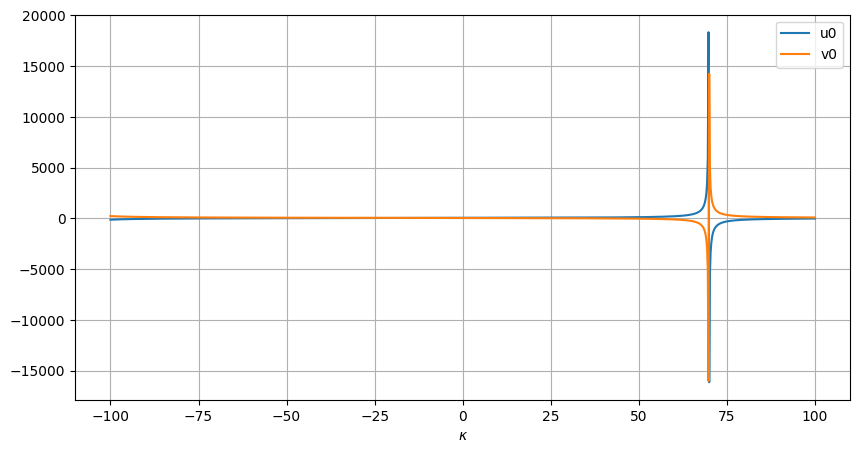

In [12]:
k_values = np.deg2rad(np.linspace(-100, 100, 1000))

u0_subs = u0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})
v0_subs = v0.subs({f: 30, xc: 32, yc: 32, u: 43, v: 35})

u0_values = [u0_subs.subs({dpsi: val}).evalf() for val in k_values]
v0_values = [v0_subs.subs({dpsi: val}).evalf() for val in k_values]

u0_values = np.array(u0_values, dtype=float)
v0_values = np.array(v0_values, dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(np.rad2deg(k_values), u0_values, label="u0")
plt.plot(np.rad2deg(k_values), v0_values, label="v0")
plt.xlabel(r"$\kappa$")
plt.legend()
plt.grid(True)
plt.show()